# 4단계 — 만성 혼잡 구간 진단

**목표:** "어디가, 언제, 얼마나" 막히는지 특정하고, **지속형과 피크형을 구분**한다.
이 구분이 중요한 이유는 **대책의 성격이 완전히 달라지기 때문**이다.

**입력:** `data/processed/hourly_panel_congestion.parquet` (3단계 산출물)
**출력:** 만성 혼잡 구간 랭킹 + 유형 분류 (7단계 개선 우선순위의 직접 근거)

---

## 시작 전 — 3단계 지표의 문제를 먼저 잡는다

3단계 결과를 세그먼트별로 펼쳐보면 **이상 신호**가 발견된다.
일부 구간이 **새벽 3시에도 혼잡**으로 판정된다. 이는 현실적으로 불가능하다.

지표를 만들었다고 끝이 아니다. **적용해보고 이상하면 원인을 찾아 고쳐야 한다.**
이 단계는 그 검증에서 시작한다.

## 셀 1 — 데이터 로드

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

mpl.rc('font', family='Malgun Gothic')
mpl.rc('axes', unicode_minus=False)

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 250)

BASE = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
PROC = BASE / 'data' / 'processed'

df = pd.read_parquet(PROC / 'hourly_panel_congestion.parquet')
KEY = ['교차로', '접근로', '이동류']
MIN_VOL = 10
THRESHOLD = 30

print('로드 완료:', df.shape)
df.head(3)

로드 완료: (411821, 21)


,교차로,AvenueSeq,접근로,MovementType,이동류,CollectedDate,교통량,대형차량,속도,대형차비율,연,월,일,시,요일,요일명,평일,날짜,자유속도,혼잡지수,혼잡
0,동막교사거리,183,동막교삼거리 방면,1,직진,2023-11-07 16:00:00,1152,139,46.241318,0.120660,2023,11,7,16,1,화,True,2023-11-07,61.610001,24.945110,False
1,동막교사거리,183,동막교삼거리 방면,1,직진,2023-11-07 17:00:00,1243,118,42.220432,0.094932,2023,11,7,17,1,화,True,2023-11-07,61.610001,31.471460,True
2,동막교사거리,183,동막교삼거리 방면,1,직진,2023-11-07 18:00:00,1232,114,42.673710,0.092532,2023,11,7,18,1,화,True,2023-11-07,61.610001,30.735743,True


---
## 1. 지표 검증 — 새벽에도 혼잡한 구간이 있다

세그먼트별·시간대별 혼잡률을 계산해 이상 패턴을 찾는다.

In [2]:
wd = df[(df.평일) & (df.교통량 >= MIN_VOL)]

seg = (wd.groupby(KEY + ['시'], observed=True)
         .agg(혼잡률=('혼잡','mean'), 표본=('혼잡','size')).reset_index())
seg = seg[seg.표본 >= 30]
seg['혼잡률'] = (seg.혼잡률 * 100).round(1)

# 혼잡률 25% 이상인 시간대가 몇 개인가 = 얼마나 오래 막히나
persist = (seg[seg.혼잡률 >= 25]
           .groupby(KEY, observed=True)
           .agg(혼잡시간수=('시','size'), 시간대=('시', lambda s: sorted(s))).reset_index())

print('=== 혼잡 시간대 수 (혼잡률 25% 이상) ===')
display(persist.sort_values('혼잡시간수', ascending=False).head(6))

=== 혼잡 시간대 수 (혼잡률 25% 이상) ===


,교차로,접근로,이동류,혼잡시간수,시간대
4,미금역사거리,정자일로 방면,우회전,24,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
2,미금역사거리,까치마을사거리 방면,우회전,22,"[0, 1, 2, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 1..."
6,미금역사거리,청송마을 사거리 방면,우회전,21,"[0, 1, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, ..."
1,동막교사거리,오리공원 방면,우회전,14,"[10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 2..."
9,오리삼거리,오리역 방면,직진,14,"[8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20..."
7,미금역사거리,청송마을 사거리 방면,직진,3,"[17, 18, 19]"


> **문제 발견:** 일부 구간이 **0~5시를 포함해 24시간 내내** 혼잡으로 판정된다.
> 새벽 3시에 교통 정체가 있을 리 없다. **지표에 문제가 있다는 신호다.**

### 1-1. 원인 추적 — 자유속도가 도달 불가능한 값인가

의심 구간의 자유속도와 실제 속도를 비교한다.

In [3]:
suspects = [('미금역사거리','정자일로 방면','우회전'),
            ('미금역사거리','청송마을 사거리 방면','우회전'),
            ('미금역사거리','까치마을사거리 방면','우회전')]

print('=== 의심 구간 진단 ===')
rows = []
for i, a, m in suspects:
    s = wd[(wd.교차로==i) & (wd.접근로==a) & (wd.이동류==m)]
    rows.append({
        '접근로': a, '이동류': m,
        '자유속도': round(s.자유속도.iloc[0], 1),
        '심야(2-4시)속도': round(s[s.시.isin([2,3,4])].속도.mean(), 1),
        '저녁(18시)속도': round(s[s.시==18].속도.mean(), 1),
    })
comp = pd.DataFrame(rows)
comp['심야가 자유속도에 못미침'] = comp['심야(2-4시)속도'] < comp['자유속도']
display(comp)

=== 의심 구간 진단 ===


,접근로,이동류,자유속도,심야(2-4시)속도,저녁(18시)속도,심야가 자유속도에 못미침
0,정자일로 방면,우회전,12.100000,9.700000,7.4,True
1,청송마을 사거리 방면,우회전,9.100000,7.500000,6.4,True
2,까치마을사거리 방면,우회전,41.900002,38.200001,28.9,True


> **핵심 문제:** 정자일로 우회전의 자유속도는 **12.1km/h**인데,
> 가장 한산한 심야에도 실제 속도가 **9.7km/h**에 그친다.
>
> **기준값이 실제로 도달 불가능한 수준으로 설정된 것이다.**
> 그러니 언제 측정해도 "기준 미달 = 혼잡"으로 판정될 수밖에 없다.

### 1-2. 왜 그런가 — 분포의 치우침

자유속도 계산에 쓰인 슬롯들의 속도 분포를 확인한다.

=== 자유속도 산출에 사용된 슬롯의 속도 분포 ===


,count,mean,std,min,25%,50%,75%,max
속도,3931.0,12.1,5.9,4.0,6.9,8.2,17.2,30.0


평균: 12.1  vs  중앙값: 8.2
속도 20km/h 초과 슬롯: 512개 (13.0%)


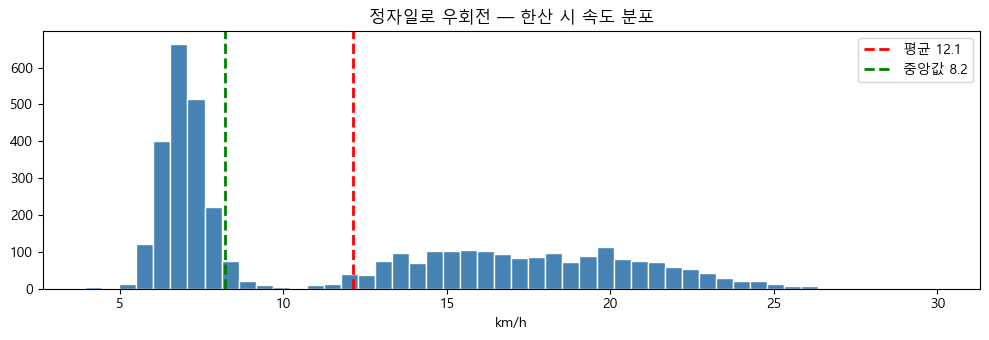

In [4]:
b = df[(df.접근로=='정자일로 방면') & (df.이동류=='우회전') & (df.교통량 >= MIN_VOL)]
q25 = b.교통량.quantile(.25)
sel = b[b.교통량 <= q25]

print('=== 자유속도 산출에 사용된 슬롯의 속도 분포 ===')
display(sel.속도.describe().round(1).to_frame().T)

print(f'평균: {sel.속도.mean():.1f}  vs  중앙값: {sel.속도.median():.1f}')
print(f'속도 20km/h 초과 슬롯: {(sel.속도>20).sum()}개 ({100*(sel.속도>20).mean():.1f}%)')

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.hist(sel.속도, bins=50, color='steelblue', edgecolor='white')
ax.axvline(sel.속도.mean(), color='red', ls='--', lw=2, label=f'평균 {sel.속도.mean():.1f}')
ax.axvline(sel.속도.median(), color='green', ls='--', lw=2, label=f'중앙값 {sel.속도.median():.1f}')
ax.set_title('정자일로 우회전 — 한산 시 속도 분포'); ax.set_xlabel('km/h'); ax.legend()
plt.tight_layout(); plt.show()

> **원인 규명:**
> 분포가 오른쪽으로 심하게 치우쳐 있다(중앙값 8.2 vs 평균 12.1).
> 소수의 고속 기록(20km/h 초과가 13%)이 **평균을 끌어올려**, 대표성 없는 기준을 만들었다.
>
> **평균은 이상치에 취약하다.** 중앙값으로 바꾸면 해결될 것으로 보인다.

### 1-3. 해결책 검증 — 평균 vs 중앙값 vs 75퍼센타일

**추측으로 바꾸지 않고, 세 후보를 같은 기준으로 비교한다.**

In [5]:
tmp = df.drop(columns=['자유속도','혼잡지수','혼잡'])
base = tmp[tmp.교통량 >= MIN_VOL]
q = base.groupby(KEY, observed=True).교통량.transform(lambda x: x.quantile(.25))
low = base[base.교통량 <= q]

results = []
for label, series in [('평균', low.groupby(KEY, observed=True).속도.mean()),
                      ('중앙값', low.groupby(KEY, observed=True).속도.median()),
                      ('75퍼센타일', low.groupby(KEY, observed=True).속도.quantile(.75))]:
    t = tmp.merge(series.rename('free'), on=KEY, how='left')
    t['ci'] = (1 - t.속도 / t.free) * 100
    w = t[(t.평일) & (t.교통량 >= MIN_VOL)]
    lab = w.ci >= THRESHOLD
    rush = lab[w.시.isin([17,18,19])].mean() * 100
    dawn = lab[w.시.isin([2,3,4,5])].mean() * 100

    s = w.assign(l=lab).groupby(KEY + ['시'], observed=True).l.mean().reset_index()
    long_seg = (s[s.l >= .25].groupby(KEY, observed=True).시.size() >= 20).sum()

    results.append({'기준': label, '전체혼잡률(%)': round(100*lab.mean(),2),
                    '러시아워(%)': round(rush,1), '새벽(%)': round(dawn,1),
                    '집중배율': round(rush/dawn,2), '20시간이상 혼잡구간': int(long_seg)})

display(pd.DataFrame(results))

,기준,전체혼잡률(%),러시아워(%),새벽(%),집중배율,20시간이상 혼잡구간
0,평균,12.03,20.4,6.6,3.10,3
1,중앙값,5.55,13.3,0.9,14.50,0
2,75퍼센타일,14.60,22.9,11.3,2.03,3


> **결정: 중앙값 채택**
>
> | 기준 | 집중배율 | 20시간 이상 혼잡 구간 | 판단 |
> |---|---|---|---|
> | 평균 | 3.10 | 3개 | 새벽 혼잡 오탐 발생 |
> | **중앙값** | **14.50** | **0개** | **채택** |
> | 75퍼센타일 | 2.03 | 3개 | 기준이 더 높아져 악화 |
>
> 중앙값 기준은 **러시아워 집중배율이 14.5배**로 압도적이고(평균 3.1배),
> **새벽 혼잡률이 0.9%까지 떨어져** 상식과 일치한다.
> 24시간 내내 혼잡한 비현실적 구간도 사라졌다.
>
> **이것이 지표를 만든 뒤 반드시 검증해야 하는 이유다.**

---
## 2. 혼잡 지수 재계산 (중앙값 기준)

전체 혼잡률: 5.36%
평일 혼잡률: 5.56%


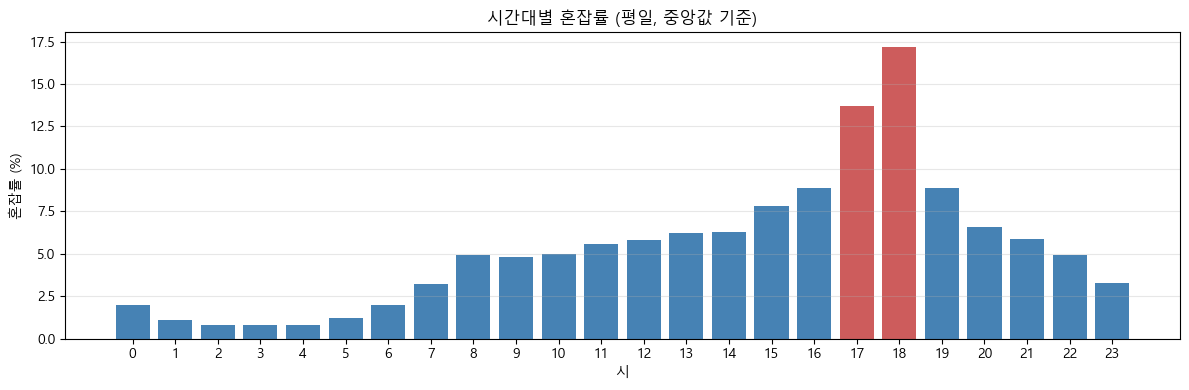

시
0      2.0
1      1.1
2      0.8
3      0.8
4      0.8
5      1.2
6      2.0
7      3.2
8      4.9
9      4.8
10     5.0
11     5.6
12     5.8
13     6.2
14     6.3
15     7.8
16     8.9
17    13.7
18    17.2
19     8.9
20     6.6
21     5.9
22     4.9
23     3.3


In [6]:
df = df.drop(columns=['자유속도','혼잡지수','혼잡'])

base = df[df.교통량 >= MIN_VOL]
q25  = base.groupby(KEY, observed=True).교통량.transform(lambda x: x.quantile(.25))
free = (base[base.교통량 <= q25]
        .groupby(KEY, observed=True).속도.median()
        .rename('자유속도').round(2))

df = df.merge(free, on=KEY, how='left')
df['혼잡지수'] = ((1 - df.속도 / df.자유속도) * 100).astype('float32')
df['혼잡'] = df.혼잡지수 >= THRESHOLD

wd = df[(df.평일) & (df.교통량 >= MIN_VOL)]

print(f'전체 혼잡률: {100*df.혼잡.mean():.2f}%')
print(f'평일 혼잡률: {100*wd.혼잡.mean():.2f}%')

hourly = (wd.groupby('시').혼잡.mean() * 100).round(1)
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(hourly.index, hourly.values,
       color=['indianred' if v >= 10 else 'steelblue' for v in hourly.values])
ax.set_title('시간대별 혼잡률 (평일, 중앙값 기준)')
ax.set_xlabel('시'); ax.set_ylabel('혼잡률 (%)'); ax.set_xticks(range(24)); ax.grid(axis='y', alpha=.3)
plt.tight_layout(); plt.show()
print(hourly.to_string())

---
## 3. 만성 혼잡 구간 랭킹

In [7]:
seg = (wd.groupby(KEY + ['시'], observed=True)
         .agg(혼잡률=('혼잡','mean'), 평균속도=('속도','mean'),
              자유속도=('자유속도','first'), 표본=('혼잡','size')).reset_index())
seg = seg[seg.표본 >= 30]
seg['혼잡률'] = (seg.혼잡률 * 100).round(1)
seg[['평균속도','자유속도']] = seg[['평균속도','자유속도']].round(1)

print('=== 평일 만성 혼잡 Top 15 ===')
display(seg.sort_values('혼잡률', ascending=False).head(15))

=== 평일 만성 혼잡 Top 15 ===


,교차로,접근로,이동류,시,혼잡률,평균속도,자유속도,표본
698,오리삼거리,오리역 방면,직진,18,87.3,11.200000,22.100000,456
435,미금역사거리,정자일로 방면,우회전,19,69.7,7.400000,8.200000,476
697,오리삼거리,오리역 방면,직진,17,68.4,14.500000,22.100000,455
436,미금역사거리,정자일로 방면,우회전,20,68.1,7.600000,8.200000,476
434,미금역사거리,정자일로 방면,우회전,18,67.9,7.400000,8.200000,477
433,미금역사거리,정자일로 방면,우회전,17,67.7,7.700000,8.200000,477
432,미금역사거리,정자일로 방면,우회전,16,67.5,7.700000,8.200000,477
290,미금역사거리,까치마을사거리 방면,우회전,18,66.6,28.900000,35.400002,311
431,미금역사거리,정자일로 방면,우회전,15,66.3,7.800000,8.200000,475
338,미금역사거리,까치마을사거리 방면,직진,18,65.6,41.799999,65.699997,346


### 3-1. 정규화의 가치 재확인

절대속도로는 놓쳤을 구간을 지수가 잡아낸다.

In [8]:
top = seg.sort_values('혼잡률', ascending=False).head(20)
fast = top[top.평균속도 > 25]

print('=== 속도는 빠르지만 심각하게 혼잡한 구간 ===')
if len(fast):
    display(fast[['접근로','이동류','시','평균속도','자유속도','혼잡률']])
    r = fast.iloc[0]
    print(f'\n{r.접근로} {r.이동류} {r.시}시는 {r.평균속도}km/h로 빠른 편이지만,')
    print(f'평소 {r.자유속도}km/h를 내던 구간이므로 혼잡률이 {r.혼잡률}%에 달한다.')
    print('절대속도 기준으로는 정상 판정을 받았을 구간이다.')

=== 속도는 빠르지만 심각하게 혼잡한 구간 ===


,접근로,이동류,시,평균속도,자유속도,혼잡률
290,까치마을사거리 방면,우회전,18,28.900000,35.400002,66.6
338,까치마을사거리 방면,직진,18,41.799999,65.699997,65.6
337,까치마을사거리 방면,직진,17,41.200001,65.699997,64.5
289,까치마을사거리 방면,우회전,17,30.200001,35.400002,61.6
291,까치마을사거리 방면,우회전,19,31.100000,35.400002,58.9
283,까치마을사거리 방면,우회전,11,31.700001,35.400002,58.2
288,까치마을사거리 방면,우회전,16,30.700001,35.400002,57.8



까치마을사거리 방면 우회전 18시는 28.899999618530273km/h로 빠른 편이지만,
평소 35.400001525878906km/h를 내던 구간이므로 혼잡률이 66.6%에 달한다.
절대속도 기준으로는 정상 판정을 받았을 구간이다.


---
## 4. 지속형 vs 피크형 분류 — 대책이 달라진다

같은 "혼잡"이라도 성격이 다르면 해법이 다르다.

- **피크형:** 특정 1~3시간만 혼잡 → 첨두시간 신호 조정으로 대응
- **지속형:** 여러 시간 연속 혼잡 → 신호 배분 구조나 도로 용량 자체의 문제

In [9]:
persist = (seg[seg.혼잡률 >= 25]
           .groupby(KEY, observed=True)
           .agg(혼잡시간수=('시','size'),
                시간대=('시', lambda s: sorted(s)),
                평균혼잡률=('혼잡률','mean')).reset_index())
persist['평균혼잡률'] = persist.평균혼잡률.round(1)

def classify(n):
    if n >= 10: return '지속형(구조적)'
    if n >= 4:  return '반지속형'
    return '피크형'

persist['유형'] = persist.혼잡시간수.apply(classify)
persist = persist.sort_values('혼잡시간수', ascending=False)

print('=== 혼잡 구간 유형 분류 ===')
display(persist)

=== 혼잡 구간 유형 분류 ===


,교차로,접근로,이동류,혼잡시간수,시간대,평균혼잡률,유형
1,미금역사거리,까치마을사거리 방면,우회전,19,"[0, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17...",53.0,지속형(구조적)
3,미금역사거리,정자일로 방면,우회전,17,"[7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, ...",58.0,지속형(구조적)
6,오리삼거리,오리역 방면,직진,6,"[14, 15, 16, 17, 18, 19]",51.4,반지속형
2,미금역사거리,까치마을사거리 방면,직진,3,"[16, 17, 18]",56.7,피크형
0,동막교사거리,동막교삼거리 방면,직진,1,[18],41.1,피크형
4,미금역사거리,청송마을 사거리 방면,직진,1,[18],25.4,피크형
5,오리삼거리,오리교1사거리 방면,우회전,1,[18],29.6,피크형


> **분류 결과:**
>
> | 구간 | 혼잡 시간 | 유형 |
> |---|---|---|
> | 미금역 까치마을사거리 방면 **우회전** | 19시간 | **지속형** |
> | 미금역 정자일로 방면 **우회전** | 17시간 | **지속형** |
> | 오리삼거리 오리역 방면 **직진** | 6시간(14~19시) | 반지속형 |
> | 미금역 까치마을사거리 방면 **직진** | 3시간(16~18시) | 피크형 |
>
> **주목할 점:** 지속형 두 곳이 모두 **우회전**이다.
> 우회전이 오후 내내 막힌다는 것은 러시아워 문제가 아니라
> **신호 배분이나 회전 차로 용량의 구조적 문제**를 시사한다.

### 4-1. 유형별 시간대 패턴 시각화

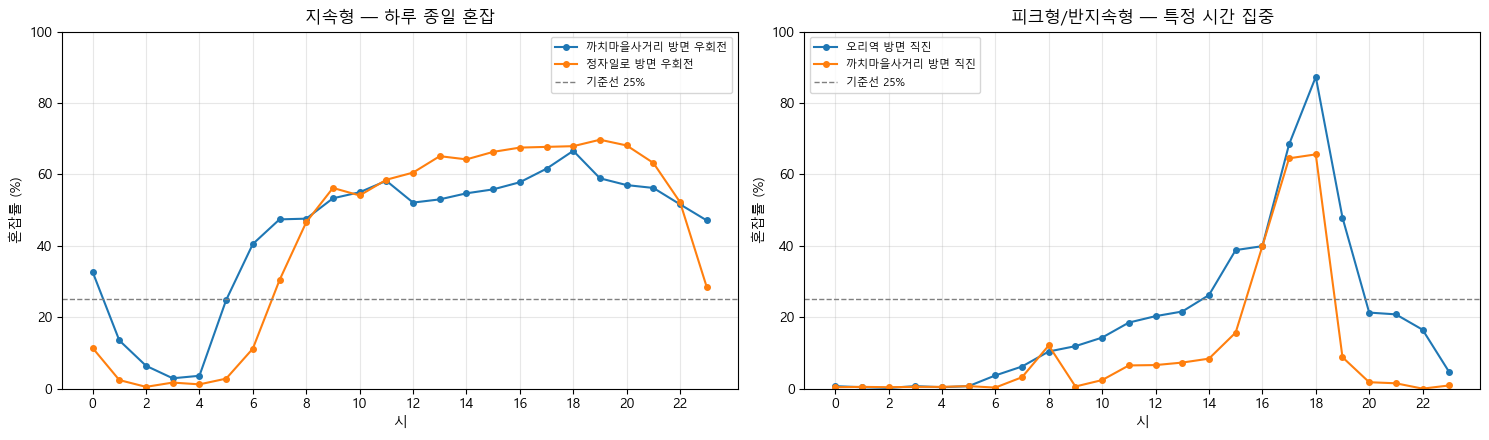

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

targets = persist.head(4)
for _, r in targets.iterrows():
    s = seg[(seg.교차로==r.교차로) & (seg.접근로==r.접근로) & (seg.이동류==r.이동류)].sort_values('시')
    ax = axes[0] if r.유형.startswith('지속') else axes[1]
    ax.plot(s.시, s.혼잡률, marker='o', ms=4, label=f'{r.접근로} {r.이동류}')

for ax, t in zip(axes, ['지속형 — 하루 종일 혼잡', '피크형/반지속형 — 특정 시간 집중']):
    ax.axhline(25, color='gray', ls='--', lw=1, label='기준선 25%')
    ax.set_title(t); ax.set_xlabel('시'); ax.set_ylabel('혼잡률 (%)')
    ax.set_xticks(range(0, 24, 2)); ax.legend(fontsize=8); ax.grid(alpha=.3); ax.set_ylim(0, 100)

plt.tight_layout(); plt.show()

---
## 5. 히트맵 — 전체 구조 한눈에 보기

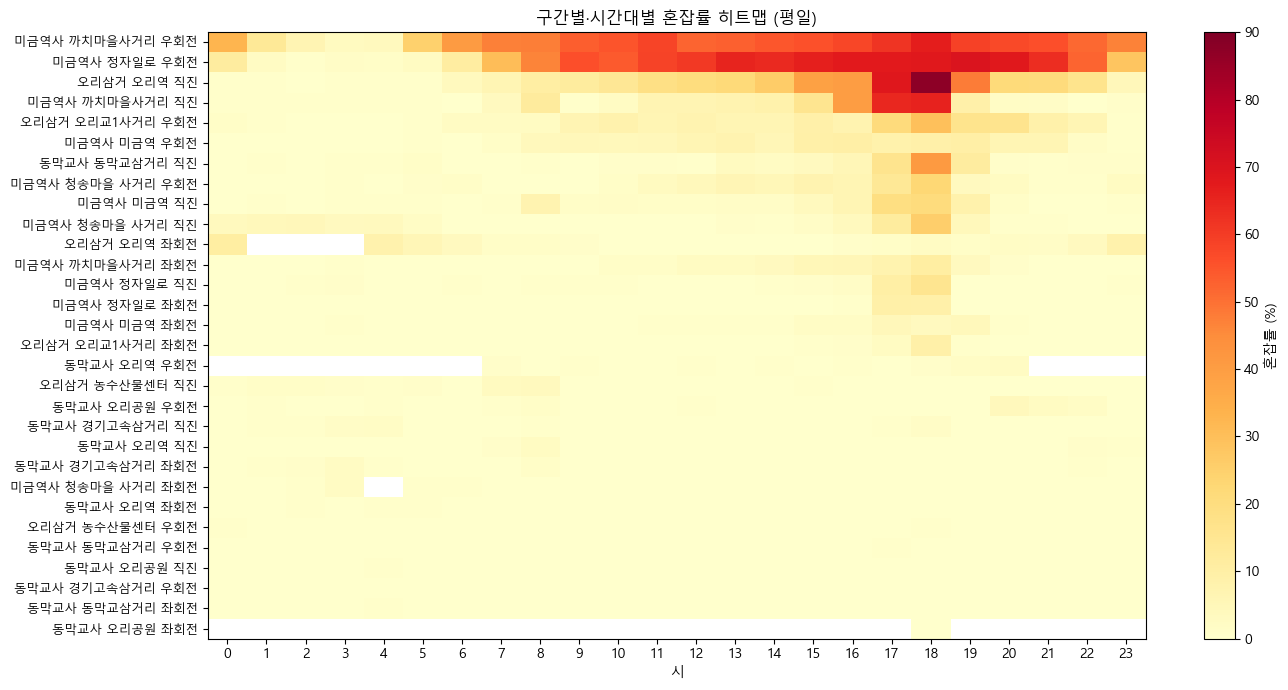

In [11]:
hm = seg.copy()
hm['구간'] = hm.교차로.astype(str).str[:4] + ' ' + hm.접근로.astype(str).str.replace(' 방면','') + ' ' + hm.이동류.astype(str)
pivot = hm.pivot_table(index='구간', columns='시', values='혼잡률', aggfunc='mean')
pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(14, 7))
im = ax.imshow(pivot.values, aspect='auto', cmap='YlOrRd', vmin=0, vmax=90)
ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)));   ax.set_yticklabels(pivot.index, fontsize=9)
ax.set_xlabel('시'); ax.set_title('구간별·시간대별 혼잡률 히트맵 (평일)')
plt.colorbar(im, ax=ax, label='혼잡률 (%)')
plt.tight_layout(); plt.show()

---
## 6. 요일·계절 패턴 (22개월 데이터 활용)

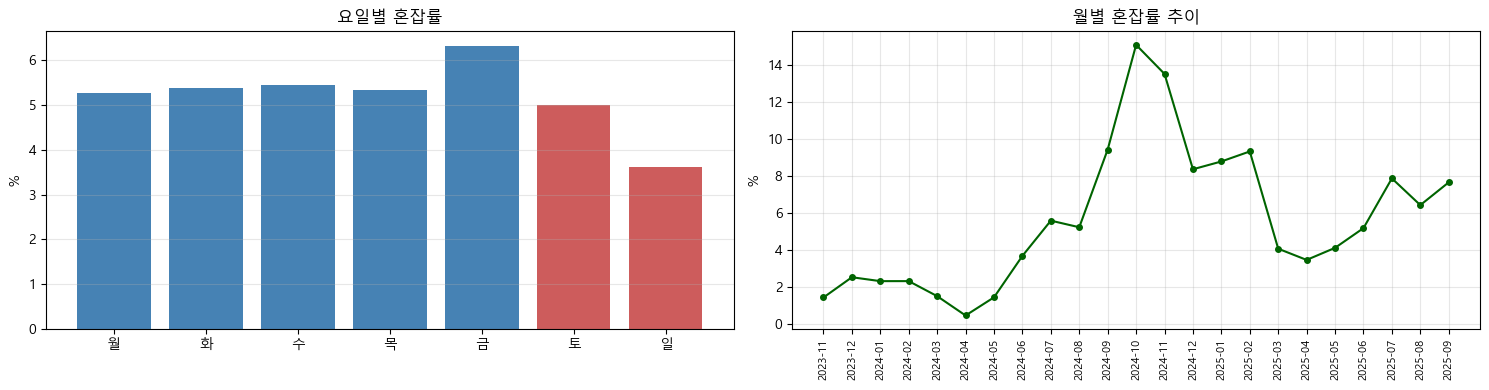

요일별 혼잡률(%):
요일명
월    5.3
화    5.4
수    5.4
목    5.3
금    6.3
토    5.0
일    3.6


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# 요일별
dow = (df[df.교통량 >= MIN_VOL].groupby('요일명', observed=True).혼잡.mean() * 100)
dow = dow.reindex(['월','화','수','목','금','토','일'])
axes[0].bar(dow.index, dow.values, color=['steelblue']*5 + ['indianred']*2)
axes[0].set_title('요일별 혼잡률'); axes[0].set_ylabel('%'); axes[0].grid(axis='y', alpha=.3)

# 월별 추이
monthly = (df[df.교통량 >= MIN_VOL]
           .groupby(df.CollectedDate.dt.to_period('M')).혼잡.mean() * 100)
axes[1].plot(monthly.index.astype(str), monthly.values, marker='o', ms=4, color='darkgreen')
axes[1].set_title('월별 혼잡률 추이'); axes[1].set_ylabel('%')
axes[1].tick_params(axis='x', rotation=90, labelsize=8); axes[1].grid(alpha=.3)

plt.tight_layout(); plt.show()

print('요일별 혼잡률(%):'); print(dow.round(1).to_string())

---
## 7. 저장

In [13]:
out = PROC / 'hourly_panel_final.parquet'
df.to_parquet(out, index=False)
print(f'저장 완료: {out}  ({out.stat().st_size/1024**2:.1f} MB, {len(df):,}행)')

seg.to_csv(PROC / 'segment_congestion.csv', index=False, encoding='utf-8-sig')
persist.drop(columns=['시간대']).to_csv(PROC / 'congestion_type.csv', index=False, encoding='utf-8-sig')
print('구간별 집계 저장 완료 (segment_congestion.csv, congestion_type.csv)')

check = pd.read_parquet(out)
print('재로드 검증:', check.shape, '— 정상' if check.shape == df.shape else '— 오류')

저장 완료: C:\Users\chpar\Exercise_CP\work\파란학기 응용\data\processed\hourly_panel_final.parquet  (6.8 MB, 411,821행)
구간별 집계 저장 완료 (segment_congestion.csv, congestion_type.csv)
재로드 검증: (411821, 21) — 정상


---
# 4단계 완료

### 이 단계의 최대 성과: 지표 오류를 발견하고 수정

3단계에서 정의한 지표를 적용해보니 **새벽 3시에도 혼잡**으로 판정되는 구간이 나왔다.
원인을 추적한 결과, 자유속도를 **평균**으로 계산해 소수의 고속 이상치가 기준을 부풀렸음을 확인했다
(정자일로 우회전: 중앙값 8.2 vs 평균 12.1 → 심야 실제 속도 9.7보다 높은 기준).

**중앙값으로 변경**하자 러시아워 집중배율이 **3.1배에서 14.5배**로 개선되고,
새벽 혼잡률은 0.9%로 떨어져 24시간 혼잡 구간이 사라졌다.

### 진단 결과

| 구간 | 혼잡 시간 | 유형 | 시사점 |
|---|---|---|---|
| 미금역 까치마을 방면 우회전 | 19시간 | 지속형 | 구조적 문제 |
| 미금역 정자일로 방면 우회전 | 17시간 | 지속형 | 구조적 문제 |
| 오리삼거리 오리역 방면 직진 | 6시간 | 반지속형 | 오후 집중 |
| 미금역 까치마을 방면 직진 | 3시간 | 피크형 | 첨두시간 대응 |

지속형 두 곳이 모두 **우회전**이라는 점이 핵심 발견이다.

### 산출물
- `hourly_panel_final.parquet` — 수정된 혼잡지수 포함 (5단계 입력)
- `segment_congestion.csv`, `congestion_type.csv` — 7단계 우선순위 근거

### 포트폴리오 서술용 메시지

> "지표를 정의한 뒤 적용해보니 새벽에도 혼잡으로 판정되는 구간이 있었다.
> 원인을 추적해 **평균이 이상치에 오염된 것**을 확인하고 중앙값으로 교체했다.
> 그 결과 러시아워 집중도가 4.7배 개선됐다. 지표는 만드는 것보다 **검증이 중요하다**."

---

### 다음 단계
**5단계 — 혼잡 예측 모델:** 1시간 후 혼잡 발생 여부를 분류 문제로 예측하고,
persistence 베이스라인과 비교해 실질적 개선을 검증한다.